In [1]:
import pandas as pd
import requests
import json
from datetime import datetime, timedelta

import sys, os
sys.path.append(os.path.abspath("../src"))

In [2]:
import numpy as np

def np_slope(y):
    if np.isnan(y).any():
        return np.nan
    return np.polyfit(np.arange(len(y)), y, 1)[0]

In [3]:
import time

from tqdm import tqdm


API = "https://en.wikipedia.org/w/api.php"
HEADERS = {"User-Agent": "thinking-bee/0.1 (t.j.wies@gmail.com)"}

def get_template_links(template_title: str) -> list[str]:
    params = {
        "action": "query",
        "format": "json",
        "prop": "links",
        "titles": template_title,
        "pllimit": "max",
        "plnamespace": 0,   # main/article namespace only
        "formatversion": 2,
    }

    titles = []
    while True:
        resp = requests.get(API, params=params, headers=HEADERS, timeout=20)
        resp.raise_for_status()
        data = resp.json()

        pages = data.get("query", {}).get("pages", [])
        if pages:
            links = pages[0].get("links", [])
            titles.extend(link["title"] for link in links)

        if "continue" in data:
            params.update(data["continue"])
        else:
            break

    return sorted(set(titles))

def get_revision_diff(parent_id, rev_id):
    params = {
        "action": "compare",
        "format": "json",
        "fromrev": parent_id,
        "torev": rev_id,
        "prop": "diff|ids|title",
        "formatversion": "2",
    }

    resp = requests.get(API, params=params, headers=HEADERS, timeout=10)
    resp.raise_for_status()
    data = resp.json()

    compare = data.get("compare", {})
    return compare.get("*") or compare.get("body") or compare.get("diff")


def get_revisions(page_title, talk=False, include_diff=False, sleep_sec=0.0):
    if talk and not page_title.startswith("Talk:"):
        page_title = "Talk:" + page_title

    params = {
        "action": "query",
        "format": "json",
        "prop": "revisions",
        "titles": page_title,
        "rvprop": "ids|timestamp|user|comment|size",
        "rvlimit": "max",
        "formatversion": "2",
    }

    all_revisions = []

    while True:
        resp = requests.get(API, params=params, headers=HEADERS, timeout=10)
        resp.raise_for_status()
        data = resp.json()

        pages = data.get("query", {}).get("pages", [])
        if pages and "revisions" in pages[0]:
            all_revisions.extend(pages[0]["revisions"])

        if "continue" in data:
            params.update(data["continue"])
        else:
            break

    df = pd.DataFrame(all_revisions)

    if df.empty:
        return df

    df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
    df["page_title"] = page_title

    if include_diff:
        diffs = []
        for _, row in df.iterrows():
            rev_id = row.get("revid")
            parent_id = row.get("parentid")

            if pd.isna(rev_id) or pd.isna(parent_id) or parent_id == 0:
                diffs.append(None)
            else:
                try:
                    diff_html = get_revision_diff(int(parent_id), int(rev_id))
                    diffs.append(diff_html)
                    if sleep_sec > 0:
                        time.sleep(sleep_sec)
                except Exception:
                    diffs.append(None)

        df["diff_html"] = diffs

    df["comment"] = df["comment"].fillna("")
    df["comment_len"] = df["comment"].str.len()
    df["has_reply"] = df["comment"].str.contains("Reply", case=False, regex=False).astype(int)
    df["has_revert"] = df["comment"].str.contains("revert", case=False, regex=True).astype(int)
    df["size_change"] = df["size"].diff().abs()

    return df

def format_revisions(revisions):

    if revisions is None:
        return pd.DataFrame()
    if revisions.empty:
        return revisions
    df = revisions
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df = df.sort_values("timestamp")
    df["timestamp"] = df["timestamp"].dt.floor("h")
    edits = df.groupby("timestamp").size().rename("edits")
    unique_editors = df.groupby("timestamp")["user"].nunique().rename("unique_editors")

    df["seen_before"] = df["user"].duplicated()
    df["new_editor"] = (~df["seen_before"]).astype(int)
    new_editors = df.groupby("timestamp")["new_editor"].sum().rename("new_editors")
    total_comment_len = df.groupby("timestamp")["comment_len"].sum().rename("total_comment_len")
    num_replies = df.groupby("timestamp")["has_reply"].sum().rename("num_replies")
    num_reverts = df.groupby("timestamp")["has_revert"].sum().rename("num_reverts")
    features = pd.concat([edits, unique_editors, new_editors, total_comment_len, num_replies, num_reverts], axis=1).fillna(0)

    return features.reset_index().sort_values("timestamp")

In [4]:
# titles = get_template_links("Template:Campaignbox 2026 Iran war")
# from tqdm import tqdm
# all_revisions = []
# features = pd.DataFrame()
# for i in tqdm(titles):
#     rev = get_revisions(i, talk=False, include_diff=False, sleep_sec=0)
#     talk_rev = get_revisions(i, talk=True, include_diff=False, sleep_sec=0)

#     if not rev.empty:
#         all_revisions.append(rev)
#     if not talk_rev.empty:
#         all_revisions.append(talk_rev)

In [5]:
all_revisions = pd.read_csv(os.path.join("..", "data", "features.csv"))
print(all_revisions.shape)
all_revisions.head()

(26660, 13)


,Unnamed: 0,revid,parentid,user,timestamp,size,comment,anon,page_title,diff_html,temp,userhidden,commenthidden
0,0,1344799148,1343955798,Fróis,2026-03-22 16:31:31+00:00,45078,/* Merge proposal */ Reply,NaN,Talk:2024 Iran–Israel conflict,"<tr>\n <td colspan=""2"" class=""diff-lineno"">Li...",NaN,NaN,NaN
1,1,1343955798,1343919767,Lova Falk,2026-03-17 11:49:32+00:00,44939,/* Merge proposal */ reply,NaN,Talk:2024 Iran–Israel conflict,"<tr>\n <td colspan=""2"" class=""diff-lineno"">Li...",NaN,NaN,NaN
2,2,1343919767,1343061185,Thebiguglyalien,2026-03-17 04:58:47+00:00,44828,/* Merge proposal */ Reply,NaN,Talk:2024 Iran–Israel conflict,"<tr>\n <td colspan=""2"" class=""diff-lineno"">Li...",NaN,NaN,NaN
3,3,1343061185,1343060908,Longhornsg,2026-03-12 01:29:13+00:00,44447,/* Merge proposal */ +,NaN,Talk:2024 Iran–Israel conflict,"<tr>\n <td colspan=""2"" class=""diff-lineno"">Li...",NaN,NaN,NaN
4,4,1343060908,1342488357,Longhornsg,2026-03-12 01:27:13+00:00,44406,/* Merge proposal */ new section,NaN,Talk:2024 Iran–Israel conflict,"<tr>\n <td colspan=""2"" class=""diff-lineno"">Li...",NaN,NaN,NaN


In [6]:
import re

def contains_keywords(text, keywords):
    if not isinstance(text, str):
        return 0
    pattern = "|".join(map(re.escape, keywords))
    return int(bool(re.search(pattern, text, flags=re.IGNORECASE)))

escalation_words = [
    "attack", "strike", "missile", "nuclear", "war", "bomb", "military"
]

uncertainty_words = [
    "report", "unconfirmed", "alleged", "rumor", "claim", "possible"
]

all_revisions["comment"] = all_revisions["comment"].fillna("")

all_revisions["has_escalation"] = all_revisions["comment"].apply(
    lambda x: contains_keywords(x, escalation_words)
)

all_revisions["has_uncertainty"] = all_revisions["comment"].apply(
    lambda x: contains_keywords(x, uncertainty_words)
)

all_revisions["seen_before_global"] = all_revisions["user"].duplicated()
all_revisions["new_editor_global"] = (~all_revisions["seen_before_global"]).astype(int)

all_revisions["comment_len"] = all_revisions["comment"].str.len()
all_revisions["has_reply"] = all_revisions["comment"].str.contains("Reply", case=False).astype(int)
all_revisions["has_revert"] = all_revisions["comment"].str.contains("revert", case=False, regex=True).astype(int)

all_revisions["size_change"] = all_revisions["size"].diff().abs()

all_revisions["timestamp"] = pd.to_datetime(all_revisions["timestamp"], utc=True)
all_revisions = all_revisions.sort_values("timestamp")
all_revisions["timestamp"] = all_revisions["timestamp"].dt.floor("h")

features = all_revisions.groupby("timestamp").agg(
    edits=("user", "count"),
    unique_editors=("user", "nunique"),
    new_editors=("new_editor_global", "sum"),
    num_seen_before_global=("seen_before_global", "sum"),
    total_comment_len=("comment_len", "sum"),
    avg_comment_len=("comment_len", "mean"),
    num_replies=("has_reply", "sum"),
    num_reverts=("has_revert", "sum"),
    num_escalation_comments=("has_escalation", "sum"),
    num_uncertainty_comments=("has_uncertainty", "sum"),
    total_size_change=("size_change", "sum"),
    max_size_change=("size_change", "max"),
).reset_index().sort_values("timestamp")
print(features.shape)
features.head()


(3386, 13)


,timestamp,edits,unique_editors,new_editors,num_seen_before_global,total_comment_len,avg_comment_len,num_replies,num_reverts,num_escalation_comments,num_uncertainty_comments,total_size_change,max_size_change
0,2004-10-02 18:00:00+00:00,2,1,1,1,54,27.0,0,0,0,0,410.0,205.0
1,2005-01-28 17:00:00+00:00,4,1,1,3,26,6.5,0,0,2,0,504.0,234.0
2,2006-01-09 16:00:00+00:00,2,1,1,1,0,0.0,0,0,0,0,1040.0,520.0
3,2006-01-30 22:00:00+00:00,2,1,1,1,0,0.0,0,0,0,0,2580.0,1290.0
4,2006-02-12 15:00:00+00:00,2,1,0,2,128,64.0,0,0,2,0,0.0,0.0


In [7]:
import importlib
import poly_utils
importlib.reload(poly_utils)
from poly_utils import get_event_slugs_paginated, get_price_series_from_slug

market_dfs = []
slugs = get_event_slugs_paginated("Iran", pages=10, limit=100)

for slug in tqdm(slugs):
    slug = slug["slug"]
    prices, meta = get_price_series_from_slug(
        slug=slug,
        days=60,
        chunk_days=7,
        interval="1h",
        fidelity=60,
    )
    market_df = prices.copy()
    market_df["market_slug"] = slug
    market_df["market_title"] = meta["market_question"]

    # compute target within this market
    market_df = market_df.sort_values("timestamp")
    # market_df["volatility_6h"] = market_df["price"].diff().rolling(6).std()
    # market_df["target"] = market_df["volatility_6h"].shift(-1)

    market_dfs.append(market_df)

100%|██████████| 10/10 [00:24<00:00,  2.44s/it]


In [8]:
panel_df = pd.concat(market_dfs, ignore_index=True)
print(panel_df.shape)
panel_df.head()

(10583, 4)


/var/folders/1r/k6vlr74j5_j3ftfp83kg694m0000gn/T/ipykernel_48776/2191102582.py:1: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  panel_df = pd.concat(market_dfs, ignore_index=True)


,timestamp,price,market_slug,market_title
0,2026-03-06 23:00:36+00:00,0.445,will-the-iranian-regime-fall-by-the-end-of-2026,Will the Iranian regime fall before 2027?
1,2026-03-07 00:00:59+00:00,0.445,will-the-iranian-regime-fall-by-the-end-of-2026,Will the Iranian regime fall before 2027?
2,2026-03-07 01:00:36+00:00,0.445,will-the-iranian-regime-fall-by-the-end-of-2026,Will the Iranian regime fall before 2027?
3,2026-03-07 02:00:34+00:00,0.445,will-the-iranian-regime-fall-by-the-end-of-2026,Will the Iranian regime fall before 2027?
4,2026-03-07 03:00:45+00:00,0.435,will-the-iranian-regime-fall-by-the-end-of-2026,Will the Iranian regime fall before 2027?


In [9]:
def validate_and_resample_panel(panel_df, freq="1h"):
    panel_df = panel_df.copy()
    panel_df["timestamp"] = pd.to_datetime(panel_df["timestamp"], utc=True)

    cleaned = []

    for slug, g in panel_df.groupby("market_slug"):
        print("\n" + "=" * 80)
        print("Market:", slug)
        print("Rows:", len(g))
        print("Time range:", g["timestamp"].min(), "→", g["timestamp"].max())

        g = g.sort_values("timestamp").drop_duplicates("timestamp").copy()
        g["delta"] = g["timestamp"].diff()

        print("\nUnique time deltas:")
        print(g["delta"].value_counts().head())

        expected = pd.Timedelta(freq)
        gaps = g[g["delta"] > expected]

        print(f"\nNumber of gaps > {freq}: {len(gaps)}")
        if len(gaps) > 0:
            print("\nExample gaps:")
            print(gaps[["timestamp", "delta"]].head())

        print("\nDuplicate timestamps:", g["timestamp"].duplicated().sum())

        # keep non-time metadata columns
        meta_cols = [c for c in g.columns if c not in ["timestamp", "price", "delta"]]

        g_clean = (
            g.set_index("timestamp")
            .resample(freq)
            .last()
            .ffill()
            .reset_index()
        )

        # restore market_slug if needed
        g_clean["market_slug"] = slug

        print("\nAfter resampling:")
        print("Rows:", len(g_clean))

        print("\nFinal time delta check:")
        print(g_clean["timestamp"].diff().value_counts().head())

        cleaned.append(g_clean)

    return pd.concat(cleaned, ignore_index=True)


panel_clean = validate_and_resample_panel(panel_df, freq="1h")

panel_clean = panel_clean.sort_values(["market_slug", "timestamp"])
panel_clean["volatility_6h"] = (
    panel_clean.groupby("market_slug")["price"]
    .transform(lambda s: s.diff().rolling(6).std())
)

panel_clean["target"] = (
    panel_clean.groupby("market_slug")["volatility_6h"]
    .shift(-1)
)


Market: iran-nuclear-test-before-2027
Rows: 1374
Time range: 2026-03-06 23:00:34+00:00 → 2026-05-05 22:50:03+00:00

Unique time deltas:
delta
0 days 01:00:00    142
0 days 01:00:01    114
0 days 00:59:59    101
0 days 01:00:02     96
0 days 00:59:58     84
Name: count, dtype: int64

Number of gaps > 1h: 649

Example gaps:
                     timestamp           delta
3426 2026-03-07 00:00:57+00:00 0 days 01:00:23
3429 2026-03-07 03:00:44+00:00 0 days 01:00:11
3431 2026-03-07 05:00:37+00:00 0 days 01:00:04
3432 2026-03-07 06:00:52+00:00 0 days 01:00:15
3434 2026-03-07 08:00:57+00:00 0 days 01:00:23

Duplicate timestamps: 0

After resampling:
Rows: 1440

Final time delta check:
timestamp
0 days 01:00:00    1439
Name: count, dtype: int64

Market: iran-nuke-before-2027
Rows: 1103
Time range: 2026-03-06 23:00:32+00:00 → 2026-05-05 22:50:05+00:00

Unique time deltas:
delta
0 days 01:00:01    72
0 days 00:59:59    67
0 days 01:00:00    63
0 days 01:00:02    62
0 days 00:59:58    48
Name: co

In [10]:
import pandas as pd
import numpy as np

# -----------------------------
# 1. Merge prices + features
# -----------------------------
# Assumes:
# panel_clean has: timestamp, market_slug, price
# features has: timestamp, edits, unique_editors, new_editors, etc.
# If features are global to all markets, merge only on timestamp.
# If features are market-specific, include market_slug and merge by market_slug too.

prices_hourly = panel_clean.copy()
prices_hourly["timestamp"] = pd.to_datetime(prices_hourly["timestamp"], utc=True)

features_hourly = (
    features.copy()
    .assign(timestamp=lambda x: pd.to_datetime(x["timestamp"], utc=True))
    .set_index("timestamp")
    .resample("1h")
    .sum()
    .fillna(0)
    .reset_index()
)

df = pd.merge_asof(
    prices_hourly.sort_values("timestamp"),
    features_hourly.sort_values("timestamp"),
    on="timestamp",
    direction="backward"
)

df = df.sort_values(["market_slug", "timestamp"]).copy()

# cutoff datapoints without matching wiki csv data
cutoff = pd.Timestamp("2026-04-09", tz="UTC")
df = df.loc[df["timestamp"] < cutoff].copy()

windows = {
    "1h": 1,
    "3h": 3,
    "6h": 6,
    # "12h": 12,
    # "24h": 24,
}

wiki_cols = list(features.columns)[1:]

new_cols = {}

# returns must be within market
new_cols["returns"] = (
    df.groupby("market_slug")["price"]
    .pct_change()
)

for label, hours in windows.items():
    g = df.groupby("market_slug", group_keys=False)

    # price targets / volatility
    new_cols[f"delta_price_{label}"] = (
        g["price"].shift(-hours) - df["price"]
    )

    new_cols[f"abs_delta_price_move_{label}"] = (
        new_cols[f"delta_price_{label}"].abs()
    )

    new_cols[f"volatility_{label}"] = (
        new_cols["returns"]
        .groupby(df["market_slug"])
        .rolling(hours, min_periods=1)
        .std()
        .reset_index(level=0, drop=True)
    )

    # wiki rolling features
    for col in wiki_cols:
        rolled = (
            df[col]
            .groupby(df["market_slug"])
            .rolling(hours, min_periods=1)
            .mean()
            .reset_index(level=0, drop=True)
        )

        new_cols[f"{col}_{label}"] = rolled
        new_cols[f"{col}_{label}_diff"] = (
            rolled.groupby(df["market_slug"]).diff()
        )

df = pd.concat([df, pd.DataFrame(new_cols, index=df.index)], axis=1).copy()
print(df.shape)
df.tail()

wiki_cols

(7137, 101)


['edits',
 'unique_editors',
 'new_editors',
 'num_seen_before_global',
 'total_comment_len',
 'avg_comment_len',
 'num_replies',
 'num_reverts',
 'num_escalation_comments',
 'num_uncertainty_comments',
 'total_size_change',
 'max_size_change']

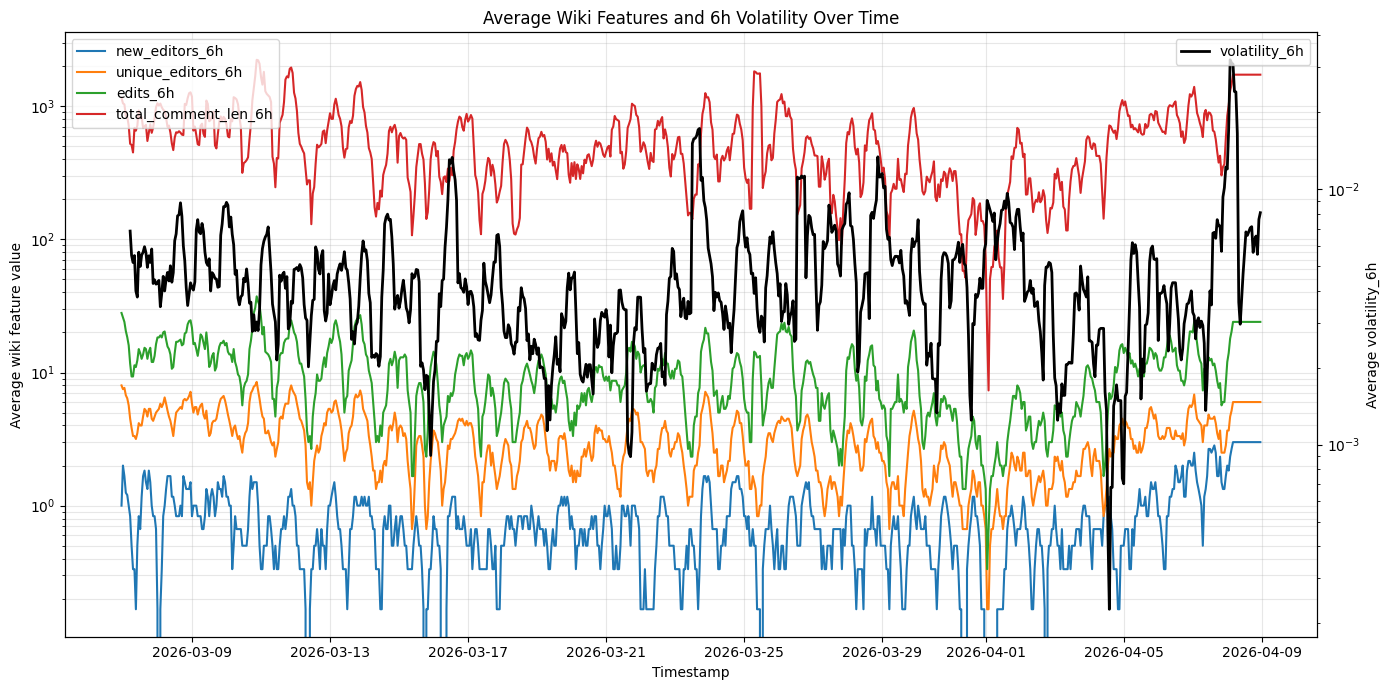

In [11]:
import matplotlib.pyplot as plt
df = df.loc[:, ~df.columns.duplicated()].copy()
features_to_plot = [
    "new_editors_6h",
    "unique_editors_6h",
    "edits_6h",
    "total_comment_len_6h",
]
agg = (
    df.sort_values("timestamp")
      .groupby("timestamp")[features_to_plot + ["volatility_6h"]]
      .mean()
      .reset_index()
)

fig, ax1 = plt.subplots(figsize=(14, 7))

for feature in features_to_plot:
    ax1.plot(agg["timestamp"], agg[feature], label=feature, linewidth=1.5)

ax1.set_xlabel("Timestamp")
ax1.set_ylabel("Average wiki feature value")
ax1.set_yscale("log")
ax1.legend(loc="upper left")
ax1.grid(alpha=0.3, which="both")

ax2 = ax1.twinx()
ax2.plot(agg["timestamp"], agg["volatility_6h"], label="volatility_6h", color="black", linewidth=2)
ax2.set_ylabel("Average volatility_6h")
ax2.set_yscale("log")
ax2.legend(loc="upper right")

plt.title("Average Wiki Features and 6h Volatility Over Time")
plt.tight_layout()
plt.show()

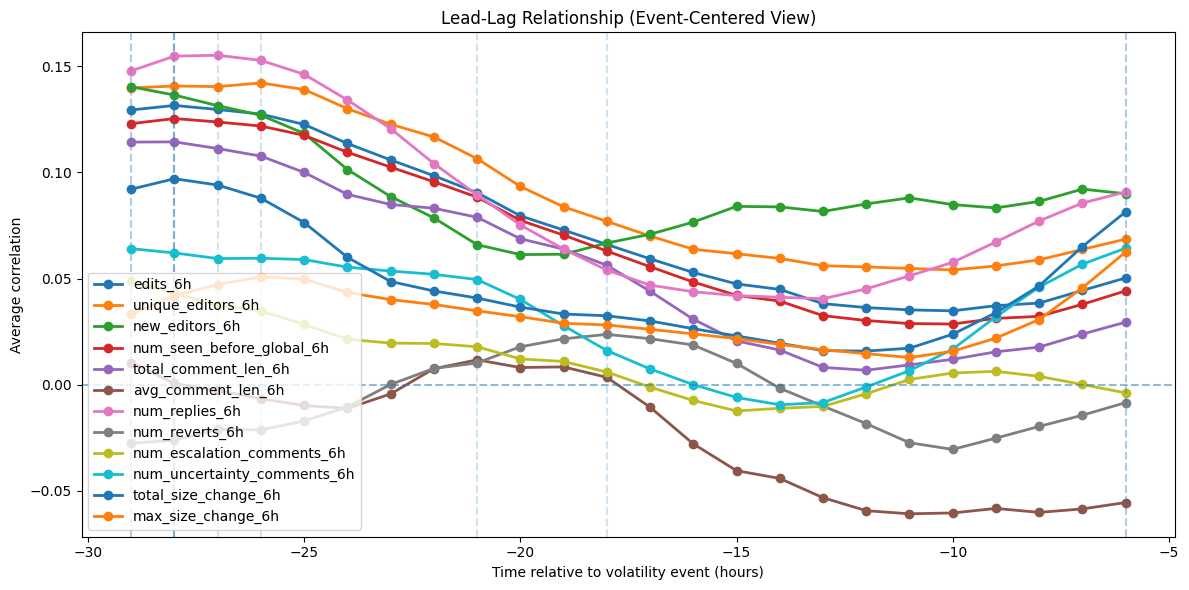

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df = df.loc[:, ~df.columns.duplicated()].copy()

features_to_plot = [col + "_6h" for col in wiki_cols]

max_lag = 24
target_horizon = 6

plt.figure(figsize=(12, 6))

for feature in features_to_plot:
    market_corrs = {}

    for slug, g in df.groupby("market_slug"):
        g = g.sort_values("timestamp").copy()

        target = g["volatility_6h"].shift(-target_horizon)

        corrs = []
        for lag in range(max_lag):
            x = g[feature].shift(lag)
            corrs.append(x.corr(target))

        market_corrs[slug] = corrs

    corr_df = pd.DataFrame(market_corrs)
    avg_corr = corr_df.mean(axis=1)

    # NEGATIVE time axis
    time_to_event = -(np.arange(max_lag) + target_horizon)

    plt.plot(
        time_to_event,
        avg_corr,
        marker="o",
        linewidth=2,
        label=feature
    )

    # mark strongest signal
    best_idx = np.argmax(avg_corr)
    best_time = -(best_idx + target_horizon)
    plt.axvline(best_time, linestyle="--", alpha=0.2)

plt.axhline(0, linestyle="--", alpha=0.5)

plt.xlabel("Time relative to volatility event (hours)")
plt.ylabel("Average correlation")
plt.title("Lead-Lag Relationship (Event-Centered View)")
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
# remove duplicate dataframe columns from repeated cell runs
df = df.loc[:, ~df.columns.duplicated()].copy()

### Text Processing with SVD

In [14]:
import re
from html import unescape
def remove_wiki_usernames(text):
    return re.sub(r"\b[a-zA-Z]*editor\d+\b", " ", text, flags=re.IGNORECASE)

def clean_html(text):
    if not isinstance(text, str):
        return ""

    # Unescape HTML entities (&amp;, &lt;, etc.)
    text = unescape(text)

    # Remove HTML tags
    text = re.sub(r"<[^>]+>", " ", text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)

    # Remove leftover markup artifacts
    text = re.sub(r"\{\{.*?\}\}", " ", text)   # templates
    text = re.sub(r"\[\[|\]\]", " ", text)     # wiki links
    text = re.sub(r"\|", " ", text)

    # Keep only words (remove weird punctuation)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # Normalize whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text.lower()

def extract_added_text(html):
    if not isinstance(html, str):
        return ""

    added = re.findall(r"<ins[^>]*>(.*?)</ins>", html, flags=re.DOTALL)
    added_text = " ".join(added)

    return clean_html(added_text)

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
import pandas as pd
import numpy as np
import spacy
from sklearn.feature_extraction.text import TfidfVectorizer

# Load spacy model (disable unneeded parts like NER for speed)
nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])

def spacy_tokenizer(text):
    # Process text through spacy pipeline
    doc = nlp(text)
    # Return lemmas that aren't stop words, punctuation, or numbers
    return [token.lemma_.lower() for token in doc 
            if not token.is_stop and not token.is_punct and token.is_alpha]

# remove old tfidf columns if they exist
tfidf_cols_existing = [c for c in df.columns if c.startswith("tfidf_svd_")]
df = df.drop(columns=tfidf_cols_existing, errors="ignore")

# -----------------------------
# 1. Prepare revision text
# -----------------------------
rev_text = all_revisions.copy()
rev_text["timestamp"] = pd.to_datetime(rev_text["timestamp"], utc=True)
rev_text["hour"] = rev_text["timestamp"].dt.floor("h")

if "diff_html" in rev_text.columns:
    rev_text["diff_html"] = rev_text["diff_html"].fillna("").astype(str)
else:
    rev_text["diff_html"] = ""

rev_text["diff_clean"] = rev_text["diff_html"].apply(extract_added_text)
rev_text["diff_clean"] = rev_text["diff_clean"].apply(remove_wiki_usernames)

# define spike threshold per market (important)
df["edit_spike"] = (
    df.groupby("market_slug")["edits"]
    .transform(lambda s: s > s.quantile(0.95))
)

# mark spike hours
spike_hours = df.loc[df["edit_spike"], "timestamp"].unique()

# filter revision text
rev_text_spikes = rev_text[rev_text["hour"].isin(spike_hours)].copy()

# -----------------------------
# 2. Define stop words BEFORE vectorizer
# -----------------------------
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

custom_stop_words = set([
    "april", "utc", "comment", "added", "isn", "listed",
    "low", "importance", "times", "using", "want", "work",
    "wp", "rs", "yes", "edit", "edited", "answered",
    "fa", "hrana", "abo", "iran", "israel"
])

stop_words = list(ENGLISH_STOP_WORDS.union(custom_stop_words))

# -----------------------------
# 3. First TF-IDF pass
# -----------------------------
vectorizer = TfidfVectorizer(
    max_features=300,
    tokenizer=spacy_tokenizer,
    min_df=10,
    max_df=0.8,
    stop_words=stop_words,
    ngram_range=(1, 1),
)

X_tfidf = vectorizer.fit_transform(rev_text_spikes["diff_clean"])
terms = vectorizer.get_feature_names_out()

# -----------------------------
# 4. Optional: discover overly common terms
# -----------------------------
term_freq = np.asarray(X_tfidf.sum(axis=0)).flatten()
common_terms = [
    terms[i]
    for i in np.where(term_freq > np.percentile(term_freq, 95))[0]
]

print("Common terms to inspect:")
print(common_terms[:30])

# -----------------------------
# 5. Optional: second TF-IDF pass with common terms removed
# -----------------------------
stop_words_2 = list(set(stop_words).union(common_terms))

vectorizer = TfidfVectorizer(
    max_features=300,
    min_df=10,
    max_df=0.8,
    stop_words=stop_words_2,
    ngram_range=(1, 1),
)

X_tfidf = vectorizer.fit_transform(rev_text["diff_clean"])
terms = vectorizer.get_feature_names_out()

# -----------------------------
# 6. SVD compression
# -----------------------------
svd = TruncatedSVD(n_components=10, random_state=42)
X_svd = svd.fit_transform(X_tfidf)

text_cols = [f"tfidf_svd_{i}" for i in range(X_svd.shape[1])]

svd_df = pd.DataFrame(
    X_svd,
    columns=text_cols,
    index=rev_text.index
)

rev_text = pd.concat([rev_text, svd_df], axis=1)

# -----------------------------
# 7. Aggregate hourly
# -----------------------------
tfidf_hourly = (
    rev_text.groupby("hour")[text_cols]
    .mean()
    .reset_index()
    .rename(columns={"hour": "timestamp"})
)

# -----------------------------
# 8. Merge into main df
# -----------------------------
df = df.loc[:, ~df.columns.duplicated()].copy()
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)

df = pd.merge_asof(
    df.sort_values("timestamp"),
    tfidf_hourly.sort_values("timestamp"),
    on="timestamp",
    direction="backward"
)

df = df.sort_values(["market_slug", "timestamp"]).copy()

print("\nAdded TF-IDF/SVD columns:")
print(text_cols)

print("\nExplained variance:")
print(svd.explained_variance_ratio_)

/Users/tallywiesenberg/Repositories/UMBC/MATH-490/thinking-bee/venv/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/Users/tallywiesenberg/Repositories/UMBC/MATH-490/thinking-bee/venv/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['add', 'answer', 'list', 'time'] not in stop_words.
  warnings.warn(


Common terms to inspect:
['war']

Added TF-IDF/SVD columns:
['tfidf_svd_0', 'tfidf_svd_1', 'tfidf_svd_2', 'tfidf_svd_3', 'tfidf_svd_4', 'tfidf_svd_5', 'tfidf_svd_6', 'tfidf_svd_7', 'tfidf_svd_8', 'tfidf_svd_9']

Explained variance:
[0.0902791  0.02471072 0.02052574 0.01947415 0.01602488 0.0142464
 0.01339004 0.0129908  0.01242657 0.01144469]


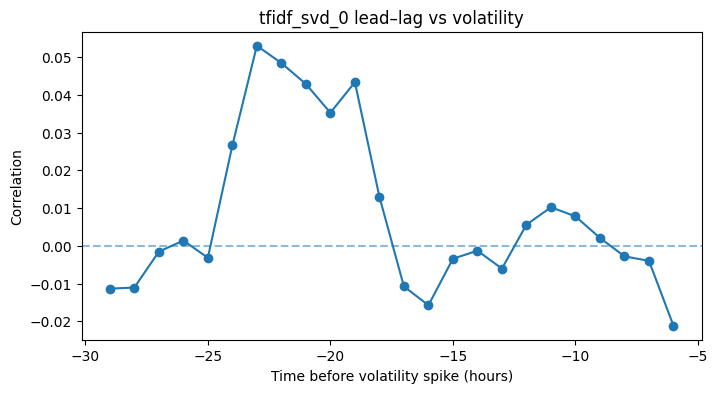

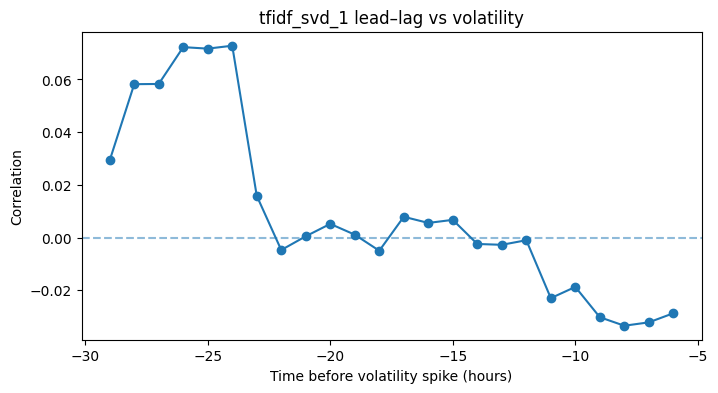

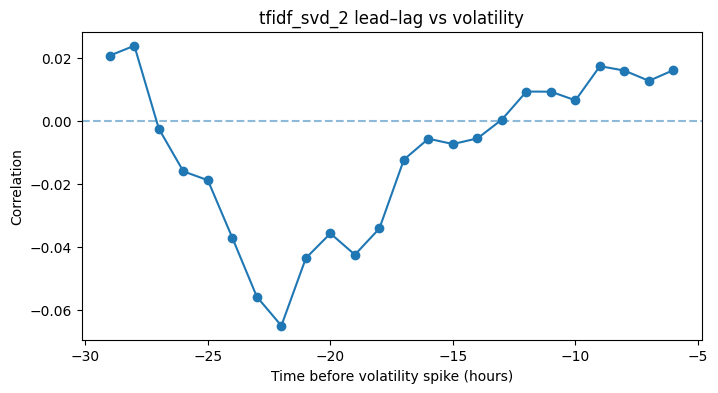

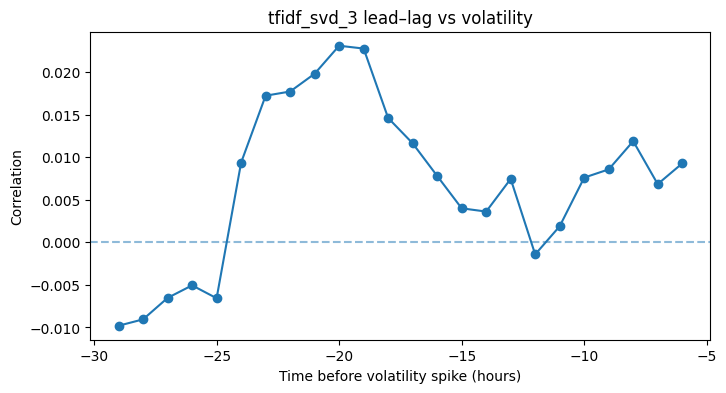

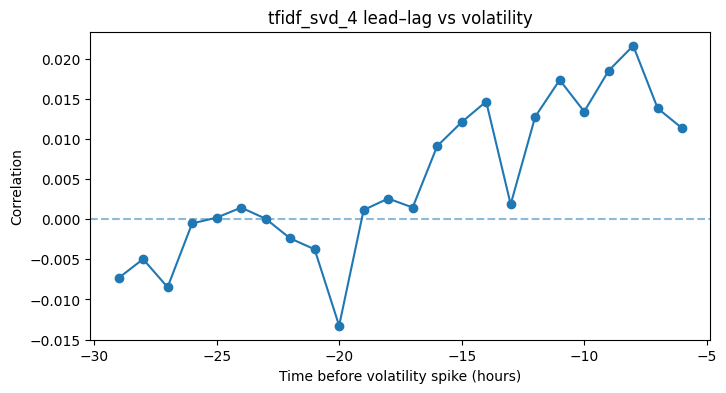

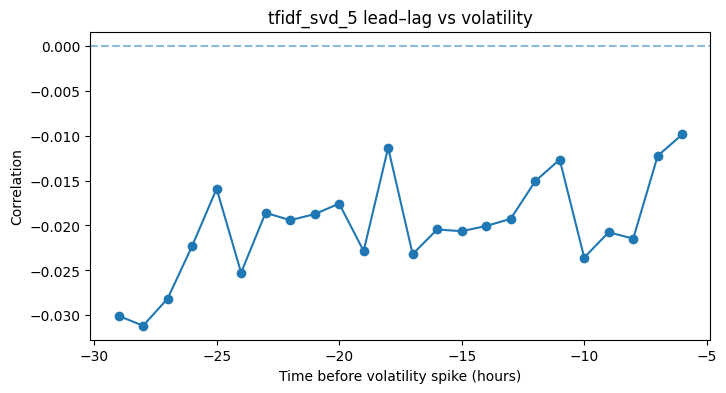

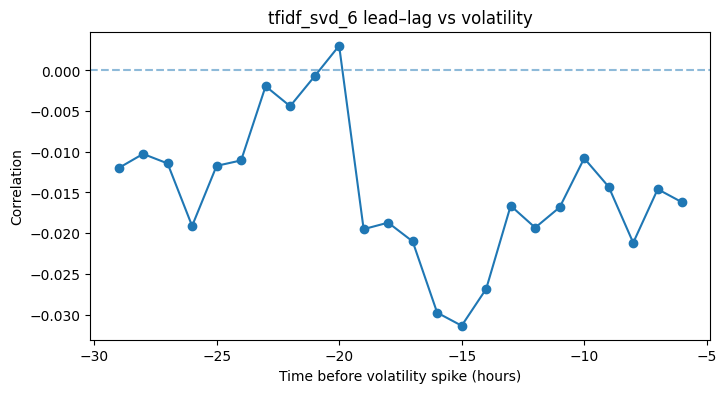

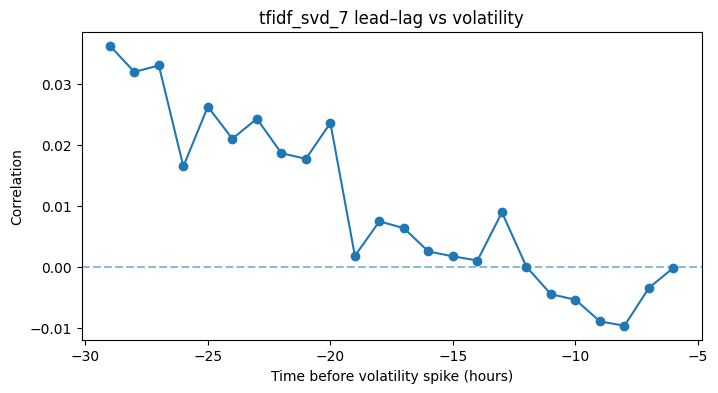

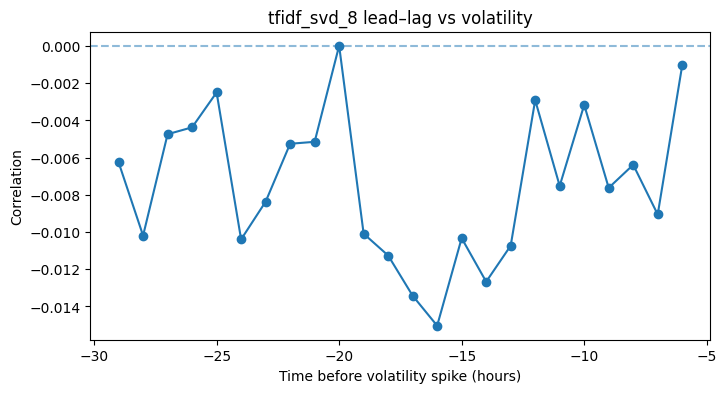

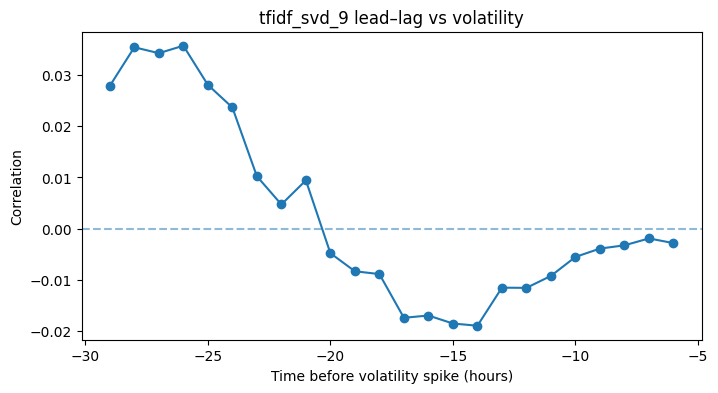

In [16]:
import matplotlib.pyplot as plt
import numpy as np

max_lag = 24
target_horizon = 6

for col in text_cols:
    corrs_all_markets = []

    for slug, g in df.groupby("market_slug"):
        g = g.sort_values("timestamp").copy()

        target = g["volatility_6h"].shift(-target_horizon)

        corrs = []
        for lag in range(max_lag):
            x = g[col].shift(lag)
            corrs.append(x.corr(target))

        corrs_all_markets.append(corrs)

    avg_corr = np.nanmean(corrs_all_markets, axis=0)

    time_axis = -(np.arange(max_lag) + target_horizon)

    plt.figure(figsize=(8, 4))
    plt.plot(time_axis, avg_corr, marker="o")
    plt.axhline(0, linestyle="--", alpha=0.5)

    plt.title(f"{col} lead–lag vs volatility")
    plt.xlabel("Time before volatility spike (hours)")
    plt.ylabel("Correlation")

    plt.show()

In [17]:
def get_topic_keywords_both_sides(svd, terms, topic_idx, top_n=15):
    weights = svd.components_[topic_idx]

    pos_idx = np.argsort(weights)[::-1][:top_n]
    neg_idx = np.argsort(weights)[:top_n]

    pos = pd.DataFrame({
        "term": terms[pos_idx],
        "weight": weights[pos_idx],
        "side": "positive"
    })

    neg = pd.DataFrame({
        "term": terms[neg_idx],
        "weight": weights[neg_idx],
        "side": "negative"
    })

    return pos, neg
terms = vectorizer.get_feature_names_out()
topic_idx = 0
pos, neg = get_topic_keywords_both_sides(svd, terms, topic_idx)

print("Positive side:")
print(pos.to_string(index=False))

print("\nNegative side:")
print(neg.to_string(index=False))

Positive side:
         term   weight     side
         user 0.692859 positive
         talk 0.642123 positive
        march 0.153112 positive
         nbsp 0.103966 positive
      special 0.103291 positive
contributions 0.103255 positive
    wikipedia 0.095990 positive
    preceding 0.093276 positive
   signatures 0.093276 positive
     unsigned 0.090539 positive
         boud 0.059819 positive
      january 0.053782 positive
         june 0.051365 positive
     contribs 0.049274 positive
     february 0.043580 positive

Negative side:
     term        weight     side
    rfcid -1.916906e-09 negative
      ans -7.449418e-10 negative
    start  1.534766e-05 negative
     gulf  1.650678e-05 negative
      blp  1.752181e-05 negative
    right  2.160925e-05 negative
    asian  2.498757e-05 negative
 national  2.553618e-05 negative
 claiming  2.673128e-05 negative
collapsed  2.759954e-05 negative
    merge  3.243874e-05 negative
   ground  3.362408e-05 negative
consensus  3.368365e-05 nega

In [18]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

df = df.copy()
df = df.sort_values(["market_slug", "timestamp"]).copy()

max_lag = 24
feature_cols = []

categories = wiki_cols

# -----------------------------
# Target
# -----------------------------
df["target_raw"] = (
    df.groupby("market_slug")["volatility_6h"]
    .shift(-1)
)

df["target_z"] = (
    df.groupby("market_slug")["target_raw"]
    .transform(lambda s: (s - s.rolling(48, min_periods=12).mean()) / s.rolling(48, min_periods=12).std())
)

df["target"] = df["target_raw"]

# -----------------------------
# Slope features
# -----------------------------
for cat in categories:
    slope_col = f"{cat}_slope_6h"
    df[slope_col] = (
        df.groupby("market_slug")[cat]
        .transform(lambda s: s.rolling(6, min_periods=5).apply(np_slope, raw=True))
    )

    # lag slope so it is past-only
    lagged_slope_col = f"{slope_col}_lag_1"
    df[lagged_slope_col] = (
        df.groupby("market_slug")[slope_col]
        .shift(1)
    )

    feature_cols.append(lagged_slope_col)

# -----------------------------
# Lag + EWM features
# -----------------------------
for w in windows:
    for cat in categories:
        cat_window = f"{cat}_{w}"

        for i in range(1, max_lag + 1, 3):
            col = f"{cat_window}_lag_{i}"
            df[col] = df.groupby("market_slug")[cat_window].shift(i)
            feature_cols.append(col)

        category_past = df.groupby("market_slug")[cat_window].shift(1)

        for alpha in [i / 10 for i in range(1, 10, 2)]:
            col = f"{cat_window}_ewm_{alpha}"
            df[col] = (
                category_past.groupby(df["market_slug"])
                .transform(lambda s: s.ewm(alpha=alpha, adjust=False).mean())
            )
            feature_cols.append(col)

df = df.copy()



# -----------------------------
# Clean model frame
# -----------------------------
model_df = pd.concat(
    [df[["market_slug", "timestamp"]], df[feature_cols], df["target"]],
    axis=1
).dropna()

model_df = model_df.sort_values("timestamp")

split = int(len(model_df) * 0.7)

train_df = model_df.iloc[:split].copy()
test_df = model_df.iloc[split:].copy()

threshold = train_df["target"].quantile(0.8)

train_df["big_move"] = (train_df["target"] > threshold).astype(int)
test_df["big_move"] = (test_df["target"] > threshold).astype(int)

print("Train class counts:")
print(train_df["big_move"].value_counts())

print("\nTest class counts:")
print(test_df["big_move"].value_counts())

if train_df["big_move"].nunique() < 2:
    raise ValueError("Training set has only one class. Lower threshold or get more data.")

X_train = train_df[feature_cols]
X_test = test_df[feature_cols]

y_train = train_df["big_move"]
y_test = test_df["big_move"]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000, C=0.05)
model.fit(X_train_scaled, y_train)

y_pred_prob = model.predict_proba(X_test_scaled)[:, 1]

auc = roc_auc_score(y_test, y_pred_prob)
print("\nAUC:", auc)

coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coef": model.coef_[0]
}).sort_values("coef", ascending=False)

print("\nTop positive coefficients:")
print(coef_df.head(10))

print("\nTop negative coefficients:")
print(coef_df.tail(10))

/var/folders/1r/k6vlr74j5_j3ftfp83kg694m0000gn/T/ipykernel_48776/1047467599.py:58: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col] = df.groupby("market_slug")[cat_window].shift(i)
/var/folders/1r/k6vlr74j5_j3ftfp83kg694m0000gn/T/ipykernel_48776/1047467599.py:58: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col] = df.groupby("market_slug")[cat_window].shift(i)
/var/folders/1r/k6vlr74j5_j3ftfp83kg694m0000gn/T/ipykernel_48776/1047467599.py:58: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result

Train class counts:
big_move
0    3884
1     967
Name: count, dtype: int64

Test class counts:
big_move
0    1620
1     459
Name: count, dtype: int64

AUC: 0.5560518034374243

Top positive coefficients:
                                 feature      coef
474            max_size_change_6h_lag_22  0.177798
473            max_size_change_6h_lag_19  0.141074
447   num_uncertainty_comments_6h_lag_19  0.133451
472            max_size_change_6h_lag_16  0.124766
317            max_size_change_3h_lag_19  0.116747
145          total_size_change_1h_lag_10  0.113869
254               num_replies_3h_ewm_0.1  0.109345
383          total_comment_len_6h_lag_22  0.105882
471            max_size_change_6h_lag_13  0.105064
449  num_uncertainty_comments_6h_ewm_0.1  0.104768

Top negative coefficients:
                             feature      coef
170                   edits_3h_lag_7 -0.106622
457      total_size_change_6h_lag_10 -0.108679
209  num_seen_before_global_3h_lag_7 -0.109487
460      total_size_

In [19]:
y_train_shuffled = y_train.sample(frac=1, random_state=42)

model.fit(X_train_scaled, y_train_shuffled)
y_pred_prob_shuffled = model.predict_proba(X_test_scaled)[:, 1]

print("Shuffled AUC:", roc_auc_score(y_test, y_pred_prob_shuffled))

Shuffled AUC: 0.4893730331638829


In [20]:
# shuffle_aucs = []

# for seed in tqdm(range(50)):
#     y_perm = y_train.sample(frac=1, random_state=seed)
#     m = LogisticRegression(max_iter=1000)
#     m.fit(X_train_scaled, y_perm)
#     pred = m.predict_proba(X_test_scaled)[:, 1]
#     shuffle_aucs.append(roc_auc_score(y_test, pred))

# print("Real AUC:", auc)
# print("Shuffle mean:", np.mean(shuffle_aucs))
# print("Shuffle max:", np.max(shuffle_aucs))

### Hawkes Process

In [21]:
import numpy as np

# -----------------------------
# 1. Select market + clean
# -----------------------------
slug = "will-the-us-invade-iran-before-2027"

g = (
    df[df["market_slug"] == slug]
    .sort_values("timestamp")
    .copy()
)

t0 = g["timestamp"].min()
t_max = g["timestamp"].max()

# -----------------------------
# 2. Define volatility spikes
# -----------------------------
threshold = g["volatility_6h"].quantile(0.8)
g["vol_spike"] = (g["volatility_6h"] > threshold).astype(int)
g["edit_burst"] = (
    g["edits"] > g["edits"].quantile(0.9)
).astype(int)

# -----------------------------
# 3. Market event times (spikes)
# -----------------------------
market_event_times = (
    (g.loc[g["vol_spike"] == 1, "timestamp"] - t0)
    .dt.total_seconds()
    / 3600
).to_numpy()

# -----------------------------
# 4. Wiki event times (raw revisions)
# -----------------------------
# wiki_event_times = (
#     (all_revisions["timestamp"] - t0)
#     .dt.total_seconds()
#     / 3600
# )

burst_times = (
    (g.loc[g["edit_burst"] == 1, "timestamp"] - t0)
    .dt.total_seconds() / 3600
)

# restrict to same time window as market
T = (t_max - t0).total_seconds() / 3600

wiki_event_times = burst_times[
    (burst_times >= 0) &
    (burst_times <= T)
].to_numpy()

# -----------------------------
# 5. Event-study function
# -----------------------------
def count_future_spikes(source_times, target_times, horizon):
    counts = []
    for t in source_times:
        n = ((target_times > t) & (target_times <= t + horizon)).sum()
        counts.append(n)
    return np.array(counts)

# -----------------------------
# 6. Run experiment
# -----------------------------
print("Avg # of volatility spikes after a wiki edit:")

for h in [1, 3, 6, 12, 24]:
    counts = count_future_spikes(wiki_event_times, market_event_times, h)
    print(f"{h}h: {counts.mean():.4f}")

Avg # of volatility spikes after a wiki edit:
1h: 0.0566
3h: 0.2264
6h: 0.4717
12h: 0.7736
24h: 2.0943


In [22]:
# -----------------------------
# 7. Compare to random baseline
# -----------------------------
rng = np.random.default_rng(42)

random_times = rng.uniform(0, T, size=len(wiki_event_times))

print("\nComparison vs random:")

for h in [1, 3, 6, 12, 24]:
    real = count_future_spikes(wiki_event_times, market_event_times, h).mean()
    rand = count_future_spikes(random_times, market_event_times, h).mean()
    
    print(f"{h}h | real: {real:.4f} | random: {rand:.4f}")

print("-------Opposite Direction-------")
for h in [1,3,6,12,24]:
    real = count_future_spikes(market_event_times, wiki_event_times, h).mean()
    rand = count_future_spikes(random_times, wiki_event_times, h).mean()
    print(f"{h}h | real: {real:.4f} | random: {rand:.4f}")


Comparison vs random:
1h | real: 0.0566 | random: 0.2453
3h | real: 0.2264 | random: 0.7170
6h | real: 0.4717 | random: 1.2075
12h | real: 0.7736 | random: 2.3396
24h | real: 2.0943 | random: 5.0755
-------Opposite Direction-------
1h | real: 0.0253 | random: 0.0377
3h | real: 0.0886 | random: 0.1132
6h | real: 0.2595 | random: 0.3208
12h | real: 0.5886 | random: 0.8868
24h | real: 1.0506 | random: 1.4340


In [23]:
diffs = count_future_spikes(wiki_event_times, market_event_times, 6) - \
        count_future_spikes(random_times, market_event_times, 6)

print("Mean diff:", diffs.mean())
print("Std diff:", diffs.std())

boot = []
rng = np.random.default_rng(0)

for _ in range(1000):
    sample = rng.choice(diffs, size=len(diffs), replace=True)
    boot.append(sample.mean())

print("95% CI:", np.percentile(boot, [2.5, 97.5]))

Mean diff: -0.7358490566037735
Std diff: 2.2997206015385037
95% CI: [-1.39622642 -0.13160377]
